# Efeito Chladni: uma aplicação da Função de Bessel

* PET Física - UFRN
* Petiano: Wallysson Pereira da Silva
* Data: 04/09/26

$\quad$ As funções de Bessel são umas das funções especiais mais conhecidas e que, consequentemente, aparecem em inúmeros contextos da física. No `Notebook` iremos primeiramente considerar um modelo descrever a vibração de uma membrana circular, onde o resultado será dado em termos de uma função de Bessel. Logo em seguida, utilizaremos esse resultado para simular a física do Efeito Chladni, criando figuras que representam visialmente determinados padrões sonoros.  

## Importando bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as sp
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator

## Informações sobre as bibliotecas

In [46]:
%load_ext version_information
%version_information Matplotlib, Numpy

Software versions
Python 3.12.7 64bit [MSC v.1929 64 bit (AMD64)]
IPython 8.29.0
OS Windows 11 10.0.26200 SP0
Matplotlib 3.9.2
Numpy 2.1.3
Sat Aug 29 15:29:23 2026 Hora oficial do Brasil

## 1. Introdução Teórica

$\quad$ Estaremos interessados em descrever os modos de vibração produzidos em uma membrana circular de raio $a$. Naturalmente, para isso teremos que considerar a equação da onda
$$
\nabla^2 \phi (r, \theta, t) - \frac{1}{c^2}\frac{\partial^2 \phi(r,\theta,t)}{\partial t^2} = 0.
\tag{1.1}
$$

$\quad$ Se pensarmos no comportamento de uma membrana circular enquanto elemento estrutural de um tambor, por exemplo, percebemos que as bordas ficam fixas indefinidamente. Assim, fisicamente, temos a seguinte condição de contorno na borda da membrana: $\phi(r = a, \theta, t) = 0$ para $\forall \theta, t$. Com a modelagem do problema já feita, podemos sumarizar que queremos obter a forma da função $\phi(r, \theta, t)$ que satisfaz tanto a Eq. (1.1) quanto a condição de contorno apresentada. 

$\quad$ Como de praxe na física, a primeira tentativa de abordagem para esse problema é feita a partir do método de separação de variáveis, com a suposição de que a função requisitada será o produto entre uma parte unicamente espacial (isto é, dependente do vetor posição $\mathbf{r}$) e outra dependente do tempo $t$. Indo além, podemos impor que a função espacial será o produto entre uma função dependente do raio $r$ e outra dependente do ângulo polar $\theta$ no plano. Dessa forma, tem-se
$$
\phi (r,\theta,t) = f(r)g(\theta)T(t).
\tag{1.2}
$$

$\quad$ Seguindo o passo clássico desse método de resolução de equações diferenciais parciais (EDP), obtemos as seguintes equações diferenciais ordinárias (EDO) desacopladas:
$$
\frac{d^2 T(t)}{dt^2} = -k^2c^2T(t),
\tag{1.3a}
$$
$$
\frac{d^2g(\theta)}{d\theta^2} = -\mu^2g(\theta),
\tag{1.3b}
$$
$$
r^2\frac{d^2f(r)}{dr^2} + r\frac{d f(r)}{dr} + (k^2r^2-\mu^2)f(r) = 0,
\tag{1.3c}
$$
onde $k^2$ e $\mu^2$ são constantes de separação. A Eq. (1.3c) pode ser posteriormente reescrita por meio da mudança de variável $x = kr$, deixando-a em uma forma mais conveniente.

$\quad$ A primeira equação é a EDO que descreve um oscilador harmônico com frequência $\omega_0 = ck$ e solução geral igual a 
$$
T(t) = \alpha \cos{(ckt)} + \beta \sin{(ckt)}.
\tag{1.4}
$$

$\quad$ De forma análoga para a solução da segunda EDO,
$$
g(\theta) = A\cos{(\mu \theta)} + B\sin{(\mu \theta)}.
\tag{1.5}
$$

$\quad$ Apesar da forma complicada da terceira equação diferencial (Eq. 1.3c), ela também é muito bem conhecida na física, denominada Equação de Bessel. Para o caso onde $\mu \in \mathbb{Z}$, a solução geral em termos da variável $x = kr$ é
$$
f(r) = CJ_\mu (kr) + D Y_\mu (kr).
\tag{1.6}
$$

$\quad$ No entanto, como $Y_\mu (kr) \to -\infty$ à medida que $kr \to 0$ (isto é, quando o raio $r \to 0$, bem no centro da membrana), temos que zerar a constante $D$, não permitindo esse estado não físico (a membrana não pode ter um deslocamento infinito no centro). Assim,
$$
f(r) = C J_\mu(kr).
\tag{1.7}
$$

$\quad$ Agora já podemos aplicar a condição de contorno $\phi(r = a,\theta, t) = 0$, obtendo
$$
\phi (r = a, \theta, t) = 0 \implies f(a)g(\theta)T(t) = 0 \implies f(a) = 0 \implies J_{\mu}(ka) = 0.
\tag{1.8}
$$

$\quad$ Para que a condição $J_{\mu}(ka) = 0$ seja satisfeita, o argumento deve ser uma raiz da função de Bessel de ordem $\mu$. Como a função de Bessel é oscilatória, cruzando o eixo horizontal várias vezes, cada ordem possui infinitos zeros. Logo, o argumento vai depender da ordem da função e de um número que o identifica como a $\nu$-ésima raiz. Dessa maneira,
$$
J_{\mu}(x) = 0 \implies x_{\mu \nu} = z_{\mu \nu}, 
\tag{1.9}
$$
onde $z_{\mu \nu}$ é a $\nu$-ésima raiz da função de Bessel do primeiro tipo de ordem $\mu$. Assim,
$$
ka = z_{\mu \nu} \implies k_{\mu \nu} = \frac{z_{\mu \nu}}{a}.
\tag{1.10}
$$
Por fim, a parte radial fica descrita como
$$
f(r) = CJ_{\mu}\left(\frac{z_{\mu \nu}}{a}r\right).
\tag{1.11}
$$

$\quad$ Dessa maneira, já podemos determinar a forma geral de $\phi(r, \theta, t)$:
$$
\phi_{\mu \nu}(r, \theta, t) = CJ_\mu\left(\frac{z_{\mu \nu} r}{a}\right)(A_{\mu \nu}\cos{(\mu \theta)} + B_{\mu \nu}\sin{(\mu \theta)}) \left[ \alpha _{\mu \nu}\cos{\left(c\frac{z_{\mu \nu}}{a}t\right)} + \beta_{\mu \nu} \sin{\left(c\frac{z_{\mu \nu}}{a}t\right)}\right].
\tag{1.12}
$$

$\quad$ Utilizando a identidade $\alpha \cos{x} + \beta \sin{x} = \sqrt{\alpha^2 + \beta^2}\cos{(x - x_0)}$, onde $x_0$ representa uma fase, e ajustando a origem dos ângulos e dos tempos para anular essas fases por simplicidade matemática, reescrevemos a solução como:
$$
\phi_{\mu \nu}(r, \theta, t) = CJ_\mu\left(\frac{z_{\mu \nu} r}{a}\right)A^{\prime} \cos{(\mu \theta)} \alpha^{\prime} \cos{\left(c\frac{z_{\mu \nu}}{a}t\right)},
\tag{1.13}
$$
com $A^{\prime}$ e $\alpha^{\prime}$ sendo novas constantes, sob as restrições $\mu \in \mathbb{Z}_{\geq 0}$ e $\nu \in \mathbb{N}^*$.

$\quad$ Como as constantes apenas afetam a amplitude máxima da oscilação, podemos igualá-las todas a $1$, e ainda assim visualizaremos a física oscilatória dos modos. Desse modo, a solução final será:
$$
\phi_{\mu \nu}(r, \theta, t) = J_{\mu}\left ( \frac{z_{\mu \nu} r }{a}\right)\cos{(\mu \theta)}\cos{\left(\frac{z_{\mu \nu }ct}{a}\right)}.
\tag{1.14}
$$

## 2. Simulação a vibração da membrana

$\quad$ Para a devida simulação, primeiro se faz necessário considerar uma discretização da nossa membrana. Isso é feito da maneira usual: geramos $N$ valores igualmente espaçados no intervalo $[0,a]$ para o raio $r$ e no intervalo $[0,2\pi]$ para o ângulo polar $\theta$. Retomando a Eq. (1.14), é possível perceber que, uma vez que decidamos qual modo iremos simular --- isto é, escolhendo efetivamente valores para $\mu$ e $\nu$ ---, toda a parte espacial $J_{\mu}\left ( \frac{z_{\mu \nu} r }{a}\right)\cos{(\mu \theta)}$ estará devidamente determinada. Assim, para realizarmos a evolução temporal, basta multiplicá-la pelo fator $\cos{\left(\frac{z_{\mu \nu }ct}{a}\right)}$, iterando desde $t = 0$ até um instante $t = t_f$ com um determinado número de passos. Feitas essas considerações, já podemos definir as variáveis para a nossa simulação, escolhendo inicialmente os modos $\mu = 2$ e $\nu = 1$.

In [51]:
mu = 2          # Modo angular (número de diâmetros nodais).
nu = 1          # Modo radial (número de círculos nodais).
a = 1.0         # Raio da membrana.
c = 1.0         # Velocidade da onda.

# Obter a nu-ésima raiz de Bessel da ordem mu.
# sp.jn_zeros retorna as primeiras 'nu' raízes; pegamos a última ([nu-1]).
z_munu = sp.jn_zeros(mu, nu)[nu - 1]

# Criação da malha polar e conversão para cartesiana (pois fica mais fácil para plotar).
r = np.linspace(0, a, 80)
theta = np.linspace(0, 2 * np.pi, 80)
R, Theta = np.meshgrid(r, theta)

X = R * np.cos(Theta)
Y = R * np.sin(Theta)

# Parte espacial fixa da equação
spatial_part = sp.jn(mu, z_munu * R / a) * np.cos(mu * Theta)
z_max = np.max(np.abs(spatial_part)) # Será usado para fixar os limites do eixo Z na animação 

$\quad$ Definida essa malha circular correspondente ao plano de repouso da membrana (plano $xy$), podemos considerar que a coordenada vertical $z$ do nosso espaço tridimensional representará simplesmente o valor da função de onda $\phi_{\mu \nu}$ naquele ponto. Em outras palavras, o deslocamento transversal da membrana ditará a altura do gráfico para cada par $(x,y)$. Para iniciar nossa visualização, fixamos o tempo em $t = 0$ e calculamos a matriz de elevação $Z$. A partir disso, utilizamos as ferramentas de projeção 3D para renderizar a superfície da membrana, configurando limites fixos para os eixos, garantindo que o gráfico não mude de escala abruptamente quando formos, no passo seguinte, animar a evolução temporal.

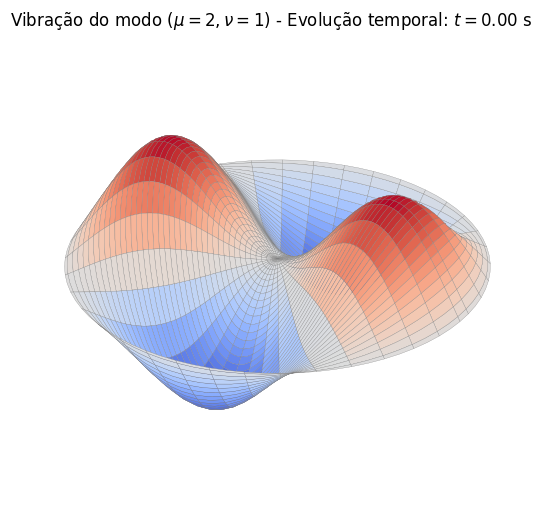

In [10]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

t = 0
Z = spatial_part * np.cos(z_munu * c * t / a)

surf = ax.plot_surface(
        X, Y, Z, 
        cmap='coolwarm', 
        vmin=-z_max, 
        vmax=z_max, 
        linewidth=0.2, 
        edgecolor='gray',
        antialiased=True
    )

ax.set_xlim(-0.7 * a, 0.7 * a)
ax.set_ylim(-0.7* a, 0.7 * a)
ax.set_zlim(-1.1 * z_max, 1.1 * z_max)

ax.set_title(f"Vibração do modo $(\\mu={mu}, \\nu={nu})$ - Evolução temporal: $t = {t:.2f}$ s")
ax.set_axis_off()

$\quad$ O plot anterior mostra simplesmente o estado da membrana no instante $t = 0$. No entanto, para visualizarmos a dinâmica do sistema, podemos definir uma função iterativa que atualiza o valor do tempo $t$ em pequenos incrementos $\Delta t$. Com isso, poderemos animar a evolução da onda e gerar um GIF que ilustra perfeitamente o comportamento físico desse modo de vibração.

In [11]:
# 3. Configuração da figura para a animação 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
plt.close() # Fecha a figura estática para não plotar em duplicidade no output

def update(frame):
    ax.clear()
    t = frame * 0.05
    
    # Adiciona a evolução temporal cos(z_munu * c * t / a)
    Z = spatial_part * np.cos(z_munu * c * t / a)
    
    surf = ax.plot_surface(
        X, Y, Z, 
        cmap='coolwarm', 
        vmin=-z_max, 
        vmax=z_max, 
        linewidth=0.2, 
        edgecolor='gray',
        antialiased=True
    )

    # CORREÇÃO: Novamente ajustando xlim e ylim para o raio 'a'
    ax.set_xlim(-0.7 * a, 0.7 * a)
    ax.set_ylim(-0.7 * a, 0.7 * a)
    ax.set_zlim(-1.1 * z_max, 1.1 * z_max)
    
    ax.set_title(f"Vibração do modo $(\\mu={mu}, \\nu={nu})$ - Evolução temporal: $t = {t:.2f}$ s")
    ax.set_axis_off()  # Oculta eixos para destacar a superfície
    
    # Removido o 'ax.plot' que estava solto e incompleto aqui
    
    return surf,

$\quad$ Agora, vamos efetivamente gerar a animação.

In [12]:
frames = 80 # Efetivamente o tempo final.
anim = FuncAnimation(fig, update, frames=frames, interval=40, blit=False)

# Salvando como GIF (opcional):
anim.save("Membrana_Vibratoria_2_1.gif", writer="pillow", fps=25)

$\quad$ Ao observarmos o resultado final da animação, fica evidente a rica dinâmica espacial do modo que escolhemos simular. Um dos aspectos mais fascinantes dessa visualização é a presença de regiões da membrana que permanecem perfeitamente estáticas durante toda a evolução temporal. Esses locais, onde a amplitude de vibração é sempre nula (isto é, $\phi = 0$ para qualquer instante $t$), formam o que chamamos de linhas e círculos nodais. A geometria e a quantidade dessas regiões de repouso são ditadas exatamente pelos "números quânticos" $\mu$ e $\nu$ que definimos no código. Como veremos a seguir, essa característica matemática, aparentemente simples, dá origem a um dos fenômenos visuais mais belos e históricos da física ondulatória.

## 3. Figuras de Chladni

$\quad$ A experiência de observar uma Figura de Chladni é o mais próximo que temos de poder "ver o som". Esse fenômeno ocorre quando a frequência de uma força externa atuando sobre uma superfície coincide com uma de suas frequências de oscilação natural, um processo conhecido como ressonância. De forma resumida, se espalharmos um número elevado de partículas (como grãos de areia) sobre essa superfície vibrante, elas serão fisicamente "expulsas" das áreas de grande amplitude e acabarão se acumulando justamente nas regiões estáticas que acabamos de discutir: as linhas nodais. Esse efeito pode ser observado em superfícies de diferentes geometrias, desde placas quadradas e circulares até triangulares. Nesta seção, simularemos a formação de um padrão de Chladni na mesma membrana circular que vínhamos utilizando.

![Chladni](../Imagens/Bessel/Chladni.png)

**Figura 1: Formação de uma Figura de Chladni** 

<p align="center">
  <img src="../Imagens/Bessel/Chladni.png" width="85%" alt="Chladni">
</p>

$\quad$ Para modelar esse fenômeno computacionalmente, assumiremos que as partículas se movem na direção do gradiente negativo da amplitude de oscilação da membrana. Em termos mais intuitivos, os grãos "deslizam morro abaixo", sentindo uma força que as direciona para as regiões onde a vibração é nula. No entanto, para tornar a simulação fisicamente mais realista, precisamos adicionar um fator estocástico (aleatório) ao nosso modelo. Esse ruído simula a natureza não pontual dos grãos, as colisões entre eles durante a vibração e as pequenas imperfeições da superfície, garantindo que o movimento não seja pura e artificialmente determinístico.

$\quad$ Para iniciar a simulação, definimos novamente as propriedades fundamentais do sistema. Reaproveitaremos os parâmetros espaciais e modais definidos na seção anterior, adicionando agora a quantidade de partículas, a velocidade de migração em direção aos nodos e a intensidade do ruído aleatório.

In [97]:
# Utilizaremos os mesmos parâmetros de antes (mu = 2, nu = 1 e a = 1.0).

N_particles = 8000  # Quantidade de grãos de areia.
step_size = 0.008    # Velocidade de migração (intensidade do movimento rumo aos nodos).
noise_std = 0.005   # Agitação estocástica (ruído para simular colisões e imperfeições).

$\quad$ A aplicação da máscara atua como um filtro espacial restritivo, funcionando de maneira análoga a uma abertura física que delimita a região de interesse. Ao zerar todos os valores fora do raio $a$ estipulado para a membrana, a máscara impede que ruídos de borda e artefatos numéricos interfiram nas extremidades da malha, concentrando a análise exclusivamente na área útil do fenômeno. 

$\quad$ Dentro desse domínio validado, o cálculo do gradiente entra para quantificar as taxas de variação espacial da amplitude de vibração. Computar o gradiente transforma a superfície escalar estática em um mapa vetorial de inclinações, evidenciando a direção das mudanças mais abruptas e destacando precisamente onde ocorrem os vales locais (linhas nodais) para os quais as partículas devem convergir. 

$\quad$ Por fim, para que toda essa informação dite o movimento de milhares de partículas de forma fluida, o uso de interpoladores se torna indispensável. Na prática, as posições dos grãos de areia na simulação são contínuas e dificilmente coincidirão com os pontos exatos da nossa malha discreta. Os interpoladores tomam esses dados rigorosamente limitados aos nós da grade e constroem uma aproximação contínua do campo de forças, permitindo estimar o vetor gradiente em coordenadas fracionárias arbitrárias. Essa ferramenta garante transições suaves e exatas, calculando a força específica que atua sobre cada partícula, independentemente de onde ela esteja sobre a membrana.

In [98]:
# Criação de uma grade cartesiana fina para calcular derivadas numéricas
grid_res = 500
x_grid = np.linspace(-a, a, grid_res)
y_grid = np.linspace(-a, a, grid_res)
X, Y = np.meshgrid(x_grid, y_grid)

R = np.hypot(X, Y)
Theta = np.arctan2(Y, X)
mask = R <= a  # Máscara para manter cálculos dentro do círculo

# Calcula a raiz de Bessel e o módulo da amplitude (Potencial U)
z_munu = sp.jn_zeros(mu, nu)[nu - 1]
phi = sp.jn(mu, z_munu * R / a) * np.cos(mu * Theta)
phi[~mask] = 0
U = phi**2  # A areia foge dos picos de amplitude

# Gradiente numérico do potencial
grad_y, grad_x = np.gradient(U, y_grid, x_grid)
Fx, Fy = -grad_x, -grad_y  # Força aponta contra o gradiente (para o zero)

# Interpoladores para calcular a força em qualquer ponto (x,y)
interp_Fx = RegularGridInterpolator((y_grid, x_grid), Fx, bounds_error=False, fill_value=0)
interp_Fy = RegularGridInterpolator((y_grid, x_grid), Fy, bounds_error=False, fill_value=0)

$\quad$ Com o campo de forças pronto e as regras de movimento estabelecidas, o próximo passo é posicionar os grãos de areia antes da "batida" no tambor. Precisamos garantir que as partículas comecem uniformemente espalhadas por toda a superfície da membrana, sem se concentrarem artificialmente no centro. Para obter uma distribuição de probabilidade verdadeiramente uniforme em um disco circular, aplicamos a raiz quadrada sobre os valores aleatórios do raio ($r_{\text{init}}$), equilibrando o elemento de área e evitando distorções geométricas. Em seguida, convertemos essas posições polares de volta para coordenadas cartesianas para facilitar o cálculo do deslocamento vetorial e da interpolação durante a animação.

In [99]:
# Espalha partículas aleatoriamente dentro do círculo
r_init = a * np.sqrt(np.random.rand(N_particles))
theta_init = 2 * np.pi * np.random.rand(N_particles)

pos_x = r_init * np.cos(theta_init)
pos_y = r_init * np.sin(theta_init)

$\quad$ Antes de iniciarmos o processo iterativo de migração dos grãos, visualizamos a configuração inicial das partículas espalhadas sobre a membrana circular. Este passo serve como validação do nosso sorteio espacial e estabelece o estado de repouso ($t = 0$) a partir do qual o padrão estocástico começará a se desenhar.

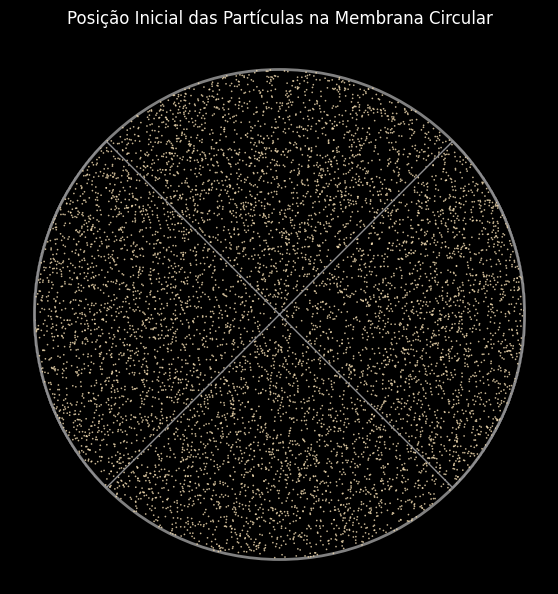

In [102]:
fig, ax = plt.subplots(figsize=(7, 7), facecolor='black')
ax.set_facecolor('black')
ax.set_aspect('equal')
ax.set_xlim(-1.1 * a, 1.1 * a)
ax.set_ylim(-1.1 * a, 1.1 * a)
ax.axis('off')

# Adicionada a cor branca ao título para destacar sobre o fundo preto
ax.set_title(f"Posição Inicial das Partículas na Membrana Circular", color='white', pad=15)


# Desenha as linhas nodais teóricas ao fundo (opcional, em cinza bem fraco)
ax.contour(X, Y, phi, levels=[0], colors="#8F8F92", linewidths=1)

# Borda da membrana
circulo = plt.Circle((0, 0), a, color='gray', fill=False, linewidth=2)
ax.add_patch(circulo)

# Plot inicial das partículas
scatter = ax.scatter(pos_x, pos_y, s=1.5, c='wheat', alpha=0.8, edgecolors='none')

$\quad$ Novamente, podemos definir uma função de atualização para evoluir a configuração do sistema em pequenos incrementos de tempo. Contudo, desta vez, é necessário calcular iterativamente o campo de forças interpolado que atua sobre a posição exata de cada partícula a cada passo temporal, somando o deslocamento determinístico à componente de agitação estocástica.

In [103]:
def update(frame):
    global pos_x, pos_y
    
    ax.set_title(f"Formação da Figura de Chladni - Evolução: {frame/150*100:.2f}%", color='white', pad=15)

    # Prepara coordenadas para o interpolador (y, x)
    pts = np.vstack((pos_y, pos_x)).T
    
    # Interpola a força vetorial no ponto exato de cada partícula
    fx = interp_Fx(pts)
    fy = interp_Fy(pts)
    
    # Atualiza posição = Força Determinística + Ruído Gaussiano
    pos_x += step_size * fx + np.random.normal(0, noise_std, N_particles)
    pos_y += step_size * fy + np.random.normal(0, noise_std, N_particles)
    
    # Condição de contorno: Remove a areia que escapa do tambor
    r_atual = np.hypot(pos_x, pos_y)
    fora = r_atual > a
    pos_x[fora] = 999
    pos_y[fora] = 999
    
    # Atualiza as posições no gráfico de espalhamento
    scatter.set_offsets(np.c_[pos_x, pos_y])
    return scatter,

$\quad$ Com a função de atualização devidamente configurada, podemos gerar a animação e exportar o GIF da evolução temporal, observando a migração progressiva dos grãos de areia até a formação completa da Figura de Chladni.

In [104]:
# Geração da animação
anim = FuncAnimation(fig, update, frames=150, interval=80, blit=True)

# Salvando a animação como GIF (corrigido o erro de digitação no nome do arquivo)
anim.save("Figura_de_Chladni.gif", writer="pillow", fps=20)

$\quad$ Ao comparar este resultado com a visualização tridimensional da oscilação da membrana, fica evidente a correspondência física entre a dinâmica vetorial e a geometria do modo: as partículas migram naturalmente das regiões de alta amplitude em direção aos locais onde o deslocamento transversal é mínimo ou nulo. Esse comportamento estocástico confirma que os grãos de areia se acumulam precisamente sobre as linhas e círculos nodais ($\phi = 0$), traduzindo um fenômeno de onda em um padrão topográfico visível que caracteriza perfeitamente o modo de vibração $(\mu, \nu)$.

## 4. Visualização Combinada

$\quad$ Para consolidar nossa análise, integramos ambas as abordagens em uma única visualização comparativa lado a lado: a oscilação tridimensional da membrana à esquerda e a dinâmica de acúmulo das partículas (Figura de Chladni) à direita. Para demonstrar a capacidade de generalização e a robustez do modelo, aplicaremos o algoritmo a um modo de vibração de ordem superior, definindo $\mu = 6$ e $\nu = 6$. Essa configuração resulta em uma topologia nodal consideravelmente mais rica e complexa, caracterizada por um número elevado de diâmetros e círculos nodais entrelaçados.

In [42]:
mu = 6          # Modo angular (número de diâmetros nodais)
nu = 6          # Modo radial (número de círculos nodais)
a = 1.0         # Raio da membrana
c = 1.0         # Velocidade da onda

# Parâmetros das partículas (Chladni)
N_particles = 10000  # Quantidade de partículas
step_size = 0.005   # Passo menor para evitar overshooting nos nós estreitos
noise_std = 0.003   # Ruído suficiente para difundir os grãos ao longo das faixas

# Raiz de Bessel z_{mu, nu}
z_munu = sp.jn_zeros(mu, nu)[nu - 1]

$\quad$ Da mesma maneira como fizemos anteriormente, iniciamos construindo a malha de discretização polar para o espaço 3D, convertendo-a para coordenadas cartesianas $(X_{\text{3D}}, Y_{\text{3D}})$. Em seguida, calculamos a parte espacial fixa da equação de onda, $J_\mu(z_{\mu\nu} r / a) \cos(\mu \theta)$, agora adaptada aos novos modos de ordem superior ($\mu = 6, \nu = 6$). A partir dessa superfície escalar, determinamos o valor de $z_{\text{max}}$, que garantirá a estabilidade da escala vertical ao longo de toda a renderização temporal.

In [43]:
# Discretização da malha polar para o plot 3D (resolução aumentada para 100x100)
r_3d = np.linspace(0, a, 100)
theta_3d = np.linspace(0, 2 * np.pi, 100)
R_3d, Theta_3d = np.meshgrid(r_3d, theta_3d)

# Conversão para coordenadas cartesianas
X_3d = R_3d * np.cos(Theta_3d)
Y_3d = R_3d * np.sin(Theta_3d)

# Parte espacial fixa da equação de onda
spatial_part = sp.jn(mu, z_munu * R_3d / a) * np.cos(mu * Theta_3d)
z_max = np.max(np.abs(spatial_part))

$\quad$ Analogamente ao procedimento realizado para o modo anterior, construímos a grade cartesiana fina necessária para determinar o potencial escalar $U = |\phi|$ associado ao modo $(\mu = 6, \nu = 6)$. A partir dessa distribuição de amplitudes, calculamos o campo vetorial de forças $(F_x, F_y) = -\nabla U$ e configuramos os interpoladores espaciais bidimensionais. Por fim, geramos a distribuição inicial uniforme das $10.000$ partículas sobre a superfície do disco, deixando o sistema bidimensional pronto para evoluir em sincronia com a membrana tridimensional.

In [45]:
# Discretização em grade cartesiana fina para o cálculo do campo vetorial 2D
grid_res = 500
x_grid = np.linspace(-a, a, grid_res)
y_grid = np.linspace(-a, a, grid_res)
X_2d, Y_2d = np.meshgrid(x_grid, y_grid)

R_2d = np.hypot(X_2d, Y_2d)
Theta_2d = np.arctan2(Y_2d, X_2d)
mask = R_2d <= a  # Máscara circular de raio 'a'

# Potencial U (módulo da amplitude de vibração)
phi = sp.jn(mu, z_munu * R_2d / a) * np.cos(mu * Theta_2d)
phi[~mask] = 0
U = phi**2  # Potencial proporcional à energia de aceleração (U = phi^2)

# Cálculo do gradiente numérico e determinação do campo de forças (-grad U)
grad_y, grad_x = np.gradient(U, y_grid, x_grid)
Fx, Fy = -grad_x, -grad_y

# Construção dos interpoladores continuos de força
interp_Fx = RegularGridInterpolator((y_grid, x_grid), Fx, bounds_error=False, fill_value=0)
interp_Fy = RegularGridInterpolator((y_grid, x_grid), Fy, bounds_error=False, fill_value=0)

# Sorteio uniforme da posição inicial das partículas dentro do disco
r_init = a * np.sqrt(np.random.rand(N_particles))
theta_init = 2 * np.pi * np.random.rand(N_particles)
pos_x = r_init * np.cos(theta_init)
pos_y = r_init * np.sin(theta_init)

$\quad$ Para inicializar a visualização simultânea no instante $t = 0$, construímos uma figura composta com dois subplots dispostos lado a lado sobre um fundo escuro contrastante. O painel da esquerda é destinado à renderização da superfície tridimensional da membrana oscilante, enquanto o painel da direita apresenta o plano bidimensional com a distribuição inicial das partículas de areia. Essa configuração estática serve como verificação fundamental da escala dos eixos e do alinhamento dos elementos visuais antes de iniciarmos a evolução dinâmica temporal.

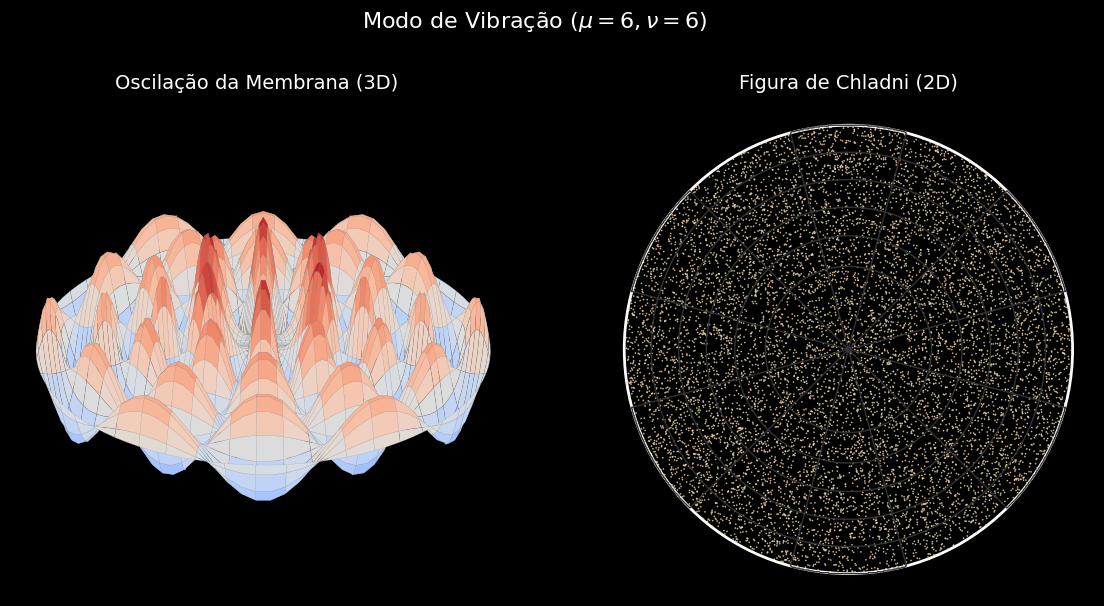

In [46]:
fig = plt.figure(figsize=(14, 7), facecolor='black')

# Subplot 1: Membrana 3D (Esquerda)
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_facecolor('black')
ax1.set_axis_off()
ax1.set_xlim(-0.7 * a, 0.7 * a)  # Corrigido para abarcar o raio completo 'a'
ax1.set_ylim(-0.7 * a, 0.7 * a)
ax1.set_zlim(-1.1 * z_max, 1.1 * z_max)
ax1.set_title('Oscilação da Membrana (3D)', color='white', fontsize=14, pad=10)

# Subplot 2: Chladni 2D (Direita)
ax2 = fig.add_subplot(122)
ax2.set_facecolor('black')
ax2.set_aspect('equal')
ax2.set_xlim(-1.1 * a, 1.1 * a)
ax2.set_ylim(-1.1 * a, 1.1 * a)
ax2.axis('off')
ax2.set_title('Figura de Chladni (2D)', color='white', fontsize=14, pad=10) # Grafia corrigida

# Elementos estáticos do painel 2D
ax2.contour(X_2d, Y_2d, phi, levels=[0], colors='#333333', linewidths=1)
circulo = plt.Circle((0, 0), a, color='white', fill=False, linewidth=2)
ax2.add_patch(circulo)
scatter = ax2.scatter(pos_x, pos_y, s=1.5, c='wheat', alpha=0.8, edgecolors='none')

# Título geral informando os números quânticos atuais
fig.suptitle(f"Modo de Vibração $(\\mu={mu}, \\nu={nu})$", color='white', fontsize=16)

# Estado da membrana em t = 0
t = 0
Z = spatial_part * np.cos(z_munu * c * t / a)

surf = ax1.plot_surface(
    X_3d, Y_3d, Z, 
    cmap='coolwarm', 
    vmin=-z_max, vmax=z_max, 
    linewidth=0.1, edgecolor='gray', antialiased=True
)

$\quad$ Para realizar a evolução temporal sincronizada de ambos os sistemas, definimos uma função de atualização iterativa que processa cada quadro da animação. No painel tridimensional, a topologia da superfície é recalculada a cada passo de tempo $t$ e re-renderizada sobre o eixo correspondente, atualizando a deflexão transversal $Z(x, y, t)$. Simultaneamente, no painel bidimensional, o algoritmo aplica o operador de interpolação sobre o conjunto discreto de partículas, adiciona o deslocamento estocástico de Langevin e impõe a condição de contorno radial, reprojetando qualquer grão que ultrapasse a borda $r = a$ de volta ao limite físico da membrana.

In [47]:
def update(frame):
    global pos_x, pos_y
    t = frame * 0.02
    
    # ------------------------------------
    # Atualiza Lado Esquerdo (3D)
    # ------------------------------------
    ax1.clear()
    ax1.set_facecolor('black')
    Z = spatial_part * np.cos(z_munu * c * t / a)
    
    surf = ax1.plot_surface(
        X_3d, Y_3d, Z, 
        cmap='coolwarm', 
        vmin=-z_max, vmax=z_max, 
        linewidth=0.1, edgecolor='gray', antialiased=True
    )
    
    # Reconfigura os limites mantendo a escala completa do raio 'a'
    ax1.set_xlim(-1.1 * a, 1.1 * a)
    ax1.set_ylim(-1.1 * a, 1.1 * a)
    ax1.set_zlim(-1.2 * z_max, 1.2 * z_max)
    ax1.set_axis_off()
    ax1.set_title(f"Oscilação da Membrana - Evolução: $t = {t:.2f}$ s", color='white', pad=10)

    # ------------------------------------
    # Atualiza Lado Direito (2D Areia)
    # ------------------------------------
    pts = np.vstack((pos_y, pos_x)).T
    fx = interp_Fx(pts)
    fy = interp_Fy(pts)

    # Movimento: Força Determinística + Ruído (agitação)
    pos_x += step_size * fx + np.random.normal(0, noise_std, N_particles)
    pos_y += step_size * fy + np.random.normal(0, noise_std, N_particles)

    # Condição de Contorno: Projeta as partículas excedentes de volta ao raio 'a'
    r_atual = np.hypot(pos_x, pos_y)
    fora = r_atual > a
    pos_x[fora] = (pos_x[fora] / r_atual[fora]) * a
    pos_y[fora] = (pos_y[fora] / r_atual[fora]) * a

    scatter.set_offsets(np.c_[pos_x, pos_y])
    ax2.set_title("Formação da Figura de Chladni", color='white', pad=10)
    
    return surf, scatter

$\quad$ Com a função de atualização devidamente instanciada para ambos os painéis, efetuamos a renderização e compilação da animação. O resultado final é exportado em formato GIF, registrando simultaneamente a oscilação tridimensional da membrana e a migração estocástica dos grãos de areia até a consolidação completa da Figura de Chladni para o modo de ordem superior $(\mu = 6, \nu = 6)$.

In [48]:
# Geração da animação sincronizada (blit=False devido à reconstrução do eixo 3D a cada frame)
ani = FuncAnimation(fig, update, frames=50, interval=50, blit=False)

# Salvamento do arquivo em formato GIF
ani.save('Chladni_Oscilacao_Combinada.gif', writer='pillow', fps=10)

## 5. Conclusão

$\quad$ Este `Notebook` apresentou uma jornada completa pelo estudo das membranas circulares vibrantes, articulando desde a fundamentação teórica baseada nas equações diferenciais parciais e funções de Bessel $J_\mu$, passando pela modelagem tridimensional da oscilação da membrana em coordenadas polares, até a formulação física das Figuras de Chladni via dinâmica estocástica sob o potencial $U = \phi^2$; a síntese final na visualização combinada lado a lado não apenas comprovou visual e numericamente a convergência dos grãos de areia para as linhas nodais de amplitude nula, como também atestou a robustez do algoritmo frente a modos de vibração complexos e de ordem elevada como $(\mu = 6, \nu = 6)$, unindo rigor matemático, modelagem computacional e intuição física em um único framework integrado.

## Referências


**[1]** 

**[2]**



O. Devauchelle, P. Popović, P. Szymczak, A. Abramian, A. Lazarus. Thermodynamics of bouncing grains.
Physical Review E , 2026, 114 (2), pp.025420. ⟨10.1103/zlsc-w7m4⟩. ⟨hal-05725479⟩